# 02b Advanced Tuning

This notebook is optimized to avoid "runs forever with no output" behavior:
- Clear progress prints in every major step
- Faster randomized search (instead of very large grid search)
- `error_score='raise'` so errors are shown immediately


In [2]:
# ============================================================
# CELL 1: Setup — Load data
# ============================================================

import os, sys, warnings
warnings.filterwarnings("ignore")

DATA_SRC = os.path.abspath(os.path.join("..", "src"))
if DATA_SRC not in sys.path:
    sys.path.insert(0, DATA_SRC)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from preprocessing import FraminghamPreProcessor

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_style("whitegrid")

DATA_PATH   = os.path.join("..", "framingham.csv")
MODELS_DIR  = os.path.join("..", "models")
REPORTS_DIR = os.path.join("..", "reports")
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

processor = FraminghamPreProcessor(
    n_neighbors=5, test_size=0.2,
    random_state=42,
    scaler_path=os.path.join(MODELS_DIR, "scaler.pkl"),
)
X_train, X_test, y_train, y_test, df = processor.fit_transform(DATA_PATH)
FEATURE_NAMES = processor.feature_names

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
SPW = round(neg / pos, 1)   # scale_pos_weight for XGBoost = 5.6

print(f"[✓] Train: {X_train.shape} | Test: {X_test.shape}")
print(f"[✓] CVD imbalance ratio (SPW): {SPW}")


[LOAD] Shape: 4240 rows × 16 columns
[LOAD] CVD prevalence: 15.19%
[LOAD] Missing values per column (only non-zero):
education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64
[IMPUTE] Total missing values after KNN: 0
[FEATS] Added engineered features. New shape: (4240, 22)
[SPLIT] Train: (3392, 21), Test: (848, 21)
[SPLIT] Train CVD rate: 15.18%, Test CVD rate: 15.21%
[SAVE] Scaler + imputer saved to: ..\models\scaler.pkl
[✓] Train: (3392, 21) | Test: (848, 21)
[✓] CVD imbalance ratio (SPW): 5.6


In [3]:
# ============================================================
# CELL 2: STAGE 1 — GridSearchCV
#
# GridSearch tries EVERY combination of the parameters you give.
# Best for: small, well-known parameter spaces
# Weakness: too slow if space is large
#
# We use a focused grid based on clinical ML literature
# ============================================================

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost                 import XGBClassifier
from sklearn.metrics         import roc_auc_score

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_results = {}

# ── LR GridSearch ─────────────────────────────────────────
print("=" * 60)
print("STAGE 1: GridSearchCV")
print("=" * 60)

print("\n[LR] Grid searching...")
lr_grid_params = {
    "C":       [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
    "penalty": ["l1", "l2"],
    "solver":  ["liblinear"],          # supports both l1 and l2
}
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    lr_grid_params, cv=cv5, scoring="roc_auc", n_jobs=-1, verbose=0
)
lr_grid.fit(X_train, y_train)
lr_test_auc = roc_auc_score(y_test, lr_grid.predict_proba(X_test)[:,1])
grid_results["Logistic Regression"] = {
    "best_params": lr_grid.best_params_,
    "cv_auc":      lr_grid.best_score_,
    "test_auc":    lr_test_auc,
    "model":       lr_grid.best_estimator_,
}
print(f"    Best params: {lr_grid.best_params_}")
print(f"    CV AUC:  {lr_grid.best_score_:.4f} | Test AUC: {lr_test_auc:.4f}")

# ── RF GridSearch ─────────────────────────────────────────
print("\n[RF] Grid searching (may take 2-3 mins)...")
rf_grid_params = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [3, 4, 5, 6],
    "min_samples_split": [5, 10, 15],
    "max_features":      ["sqrt", "log2"],
}
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    rf_grid_params, cv=cv5, scoring="roc_auc", n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)
rf_test_auc = roc_auc_score(y_test, rf_grid.predict_proba(X_test)[:,1])
grid_results["Random Forest"] = {
    "best_params": rf_grid.best_params_,
    "cv_auc":      rf_grid.best_score_,
    "test_auc":    rf_test_auc,
    "model":       rf_grid.best_estimator_,
}
print(f"    Best params: {rf_grid.best_params_}")
print(f"    CV AUC:  {rf_grid.best_score_:.4f} | Test AUC: {rf_test_auc:.4f}")

# ── XGB GridSearch ────────────────────────────────────────
print("\n[XGB] Grid searching (may take 3-4 mins)...")
xgb_grid_params = {
    "n_estimators":  [100, 200, 300],
    "max_depth":     [2, 3, 4],
    "learning_rate": [0.005, 0.01, 0.05],
    "subsample":     [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}
xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=SPW, eval_metric="logloss",
                  random_state=42, verbosity=0),
    xgb_grid_params, cv=cv5, scoring="roc_auc", n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train, y_train)
xgb_test_auc = roc_auc_score(y_test, xgb_grid.predict_proba(X_test)[:,1])
grid_results["XGBoost"] = {
    "best_params": xgb_grid.best_params_,
    "cv_auc":      xgb_grid.best_score_,
    "test_auc":    xgb_test_auc,
    "model":       xgb_grid.best_estimator_,
}
print(f"    Best params: {xgb_grid.best_params_}")
print(f"    CV AUC:  {xgb_grid.best_score_:.4f} | Test AUC: {xgb_test_auc:.4f}")

print("\n[✓] Stage 1 GridSearchCV complete")
print(f"{'Model':<25} {'CV AUC':>10} {'Test AUC':>10}")
print("-" * 47)
for name, r in grid_results.items():
    print(f"{name:<25} {r['cv_auc']:>10.4f} {r['test_auc']:>10.4f}")


STAGE 1: GridSearchCV

[LR] Grid searching...
    Best params: {'C': 0.05, 'penalty': 'l2', 'solver': 'liblinear'}
    CV AUC:  0.7308 | Test AUC: 0.6943

[RF] Grid searching (may take 2-3 mins)...
    Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 15, 'n_estimators': 300}
    CV AUC:  0.7194 | Test AUC: 0.6712

[XGB] Grid searching (may take 3-4 mins)...
    Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.7}
    CV AUC:  0.7204 | Test AUC: 0.6834

[✓] Stage 1 GridSearchCV complete
Model                         CV AUC   Test AUC
-----------------------------------------------
Logistic Regression           0.7308     0.6943
Random Forest                 0.7194     0.6712
XGBoost                       0.7204     0.6834


In [5]:
# ============================================================
# CELL 3: STAGE 2 — RandomizedSearchCV
#
# RandomizedSearch samples RANDOM combinations from a much
# WIDER parameter space. You define distributions, not lists.
#
# Why use this after GridSearch?
# GridSearch only finds best within YOUR predefined grid.
# Maybe the true optimum is at C=0.073 — not in your list.
# RandomSearch explores continuous distributions, finding
# values you might never think to include in a grid.
#
# We run n_iter=100 random combinations — much faster than
# exhaustive search but covers a far wider space.
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats             import uniform, randint, loguniform

random_results = {}

print("=" * 60)
print("STAGE 2: RandomizedSearchCV  (n_iter=100 per model)")
print("=" * 60)

# ── LR RandomSearch ───────────────────────────────────────
print("\n[LR] Random searching...")
lr_rand_params = {
    "C":       loguniform(0.0001, 20),    # log-uniform: samples more from small values
    "penalty": ["l1", "l2"],
    "solver":  ["liblinear"],
}
lr_rand = RandomizedSearchCV(
    LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    lr_rand_params, n_iter=100,
    cv=cv5, scoring="roc_auc", n_jobs=-1,
    random_state=42, verbose=0
)
lr_rand.fit(X_train, y_train)
lr_rand_test_auc = roc_auc_score(y_test, lr_rand.predict_proba(X_test)[:,1])
random_results["Logistic Regression"] = {
    "best_params": lr_rand.best_params_,
    "cv_auc":      lr_rand.best_score_,
    "test_auc":    lr_rand_test_auc,
    "model":       lr_rand.best_estimator_,
}
print(f"    Best C: {lr_rand.best_params_['C']:.5f}  penalty: {lr_rand.best_params_['penalty']}")
print(f"    CV AUC:  {lr_rand.best_score_:.4f} | Test AUC: {lr_rand_test_auc:.4f}")

# ── RF RandomSearch ───────────────────────────────────────
print("\n[RF] Random searching...")
rf_rand_params = {
    "n_estimators":      randint(50, 500),
    "max_depth":         [2, 3, 4, 5, 6, 7, 8, None],
    "min_samples_split": randint(2, 30),
    "min_samples_leaf":  randint(1, 20),
    "max_features":      ["sqrt", "log2", 0.3, 0.5, 0.7],
    "bootstrap":         [True, False],
}
rf_rand = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    rf_rand_params, n_iter=100,
    cv=cv5, scoring="roc_auc", n_jobs=-1,
    random_state=42, verbose=0
)
rf_rand.fit(X_train, y_train)
rf_rand_test_auc = roc_auc_score(y_test, rf_rand.predict_proba(X_test)[:,1])
random_results["Random Forest"] = {
    "best_params": rf_rand.best_params_,
    "cv_auc":      rf_rand.best_score_,
    "test_auc":    rf_rand_test_auc,
    "model":       rf_rand.best_estimator_,
}
print(f"    Best params: {rf_rand.best_params_}")
print(f"    CV AUC:  {rf_rand.best_score_:.4f} | Test AUC: {rf_rand_test_auc:.4f}")

# ── XGB RandomSearch ──────────────────────────────────────
print("\n[XGB] Random searching...")
xgb_rand_params = {
    "n_estimators":       randint(100, 600),
    "max_depth":          randint(2, 8),
    "learning_rate":      loguniform(0.001, 0.3),
    "subsample":          uniform(0.5, 0.5),       # 0.5 to 1.0
    "colsample_bytree":   uniform(0.5, 0.5),       # 0.5 to 1.0
    "min_child_weight":   randint(1, 10),
    "gamma":              uniform(0, 0.5),
    "reg_alpha":          loguniform(0.001, 10),   # L1 regularization
    "reg_lambda":         loguniform(0.1, 10),     # L2 regularization
}
xgb_rand = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=SPW, eval_metric="logloss",
                  random_state=42, verbosity=0),
    xgb_rand_params, n_iter=100,
    cv=cv5, scoring="roc_auc", n_jobs=-1,
    random_state=42, verbose=0
)
xgb_rand.fit(X_train, y_train)
xgb_rand_test_auc = roc_auc_score(y_test, xgb_rand.predict_proba(X_test)[:,1])
random_results["XGBoost"] = {
    "best_params": xgb_rand.best_params_,
    "cv_auc":      xgb_rand.best_score_,
    "test_auc":    xgb_rand_test_auc,
    "model":       xgb_rand.best_estimator_,
}
print(f"    Best params: {xgb_rand.best_params_}")
print(f"    CV AUC:  {xgb_rand.best_score_:.4f} | Test AUC: {xgb_rand_test_auc:.4f}")

print("\n[✓] Stage 2 RandomizedSearch complete")
print(f"\n{'Model':<25} {'Grid CV':>10} {'Rand CV':>10} {'Improvement':>12}")
print("-" * 60)
for name in grid_results:
    g = grid_results[name]["cv_auc"]
    r = random_results[name]["cv_auc"]
    print(f"{name:<25} {g:>10.4f} {r:>10.4f} {r-g:>+12.4f}")


STAGE 2: RandomizedSearchCV  (n_iter=100 per model)

[LR] Random searching...
    Best C: 0.17474  penalty: l1
    CV AUC:  0.7309 | Test AUC: 0.6970

[RF] Random searching...
    Best params: {'bootstrap': True, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 26, 'n_estimators': 332}
    CV AUC:  0.7201 | Test AUC: 0.6646

[XGB] Random searching...
    Best params: {'colsample_bytree': 0.618753235646235, 'gamma': 0.20011144643601242, 'learning_rate': 0.015253085683467048, 'max_depth': 2, 'min_child_weight': 8, 'n_estimators': 516, 'reg_alpha': 0.007841214856323655, 'reg_lambda': 8.441994772287126, 'subsample': 0.5060772373449082}
    CV AUC:  0.7219 | Test AUC: 0.6844

[✓] Stage 2 RandomizedSearch complete

Model                        Grid CV    Rand CV  Improvement
------------------------------------------------------------
Logistic Regression           0.7308     0.7309      +0.0001
Random Forest                 0.7194     0.7201      +0.0007
XG

In [7]:
# ============================================================
# CELL 4: STAGE 3 — Bayesian Optimization
#
# Bayesian Optimization is the most intelligent tuning method.
# It works like a smart student taking multiple choice test:
#
# Grid/Random: "Let me try all 243 combinations blindly"
# Bayesian:    "I tried C=0.1 (good) and C=10 (bad).
#               The optimum is probably around C=0.3.
#               Let me focus my next tries near C=0.3."
#
# It builds a probabilistic model (Gaussian Process) of the
# objective function and uses it to pick the most PROMISING
# next parameter combination to try.
#
# Result: finds better parameters with FEWER evaluations.
# ============================================================

# Install if needed: pip install scikit-optimize
try:
    from skopt import BayesSearchCV
    from skopt.space import Real, Integer, Categorical
    SKOPT_AVAILABLE = True
    print("[✓] scikit-optimize available")
except ImportError:
    SKOPT_AVAILABLE = False
    print("[!] scikit-optimize not installed.")
    print("[!] Run in terminal: pip install scikit-optimize")
    print("[!] Then restart kernel and re-run this cell")

if SKOPT_AVAILABLE:
    bayes_results = {}

    print("\n" + "=" * 60)
    print("STAGE 3: Bayesian Optimization  (n_iter=50 per model)")
    print("=" * 60)

    # ── LR BayesSearch ────────────────────────────────────
    print("\n[LR] Bayesian optimizing...")
    lr_bayes_space = {
        "C":       Real(0.0001, 20.0, prior="log-uniform"),
        "penalty": Categorical(["l1", "l2"]),
        "solver":  Categorical(["liblinear"]),
    }
    lr_bayes = BayesSearchCV(
        LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
        lr_bayes_space, n_iter=50,
        cv=cv5, scoring="roc_auc", n_jobs=-1,
        random_state=42, verbose=0
    )
    lr_bayes.fit(X_train, y_train)
    lr_bayes_test_auc = roc_auc_score(y_test, lr_bayes.predict_proba(X_test)[:,1])
    bayes_results["Logistic Regression"] = {
        "best_params": dict(lr_bayes.best_params_),
        "cv_auc":      lr_bayes.best_score_,
        "test_auc":    lr_bayes_test_auc,
        "model":       lr_bayes.best_estimator_,
    }
    print(f"    Best C: {lr_bayes.best_params_['C']:.6f}  penalty: {lr_bayes.best_params_['penalty']}")
    print(f"    CV AUC:  {lr_bayes.best_score_:.4f} | Test AUC: {lr_bayes_test_auc:.4f}")

    # ── RF BayesSearch ────────────────────────────────────
    print("\n[RF] Bayesian optimizing...")
    rf_bayes_space = {
        "n_estimators":      Integer(50, 500),
        "max_depth":         Integer(2, 10),
        "min_samples_split": Integer(2, 30),
        "min_samples_leaf":  Integer(1, 20),
        "max_features":      Real(0.1, 1.0, prior="uniform"),
    }
    rf_bayes = BayesSearchCV(
        RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        rf_bayes_space, n_iter=50,
        cv=cv5, scoring="roc_auc", n_jobs=-1,
        random_state=42, verbose=0
    )
    rf_bayes.fit(X_train, y_train)
    rf_bayes_test_auc = roc_auc_score(y_test, rf_bayes.predict_proba(X_test)[:,1])
    bayes_results["Random Forest"] = {
        "best_params": dict(rf_bayes.best_params_),
        "cv_auc":      rf_bayes.best_score_,
        "test_auc":    rf_bayes_test_auc,
        "model":       rf_bayes.best_estimator_,
    }
    print(f"    Best params: {rf_bayes.best_params_}")
    print(f"    CV AUC:  {rf_bayes.best_score_:.4f} | Test AUC: {rf_bayes_test_auc:.4f}")

    # ── XGB BayesSearch ───────────────────────────────────
    print("\n[XGB] Bayesian optimizing (this may take 5-8 mins)...")
    xgb_bayes_space = {
        "n_estimators":     Integer(100, 600),
        "max_depth":        Integer(2, 8),
        "learning_rate":    Real(0.001, 0.3, prior="log-uniform"),
        "subsample":        Real(0.5, 1.0, prior="uniform"),
        "colsample_bytree": Real(0.5, 1.0, prior="uniform"),
        "min_child_weight": Integer(1, 10),
        "gamma":            Real(0.0, 0.5, prior="uniform"),
        "reg_alpha":        Real(0.001, 10.0, prior="log-uniform"),
        "reg_lambda":       Real(0.1,  10.0, prior="log-uniform"),
    }
    xgb_bayes = BayesSearchCV(
        XGBClassifier(scale_pos_weight=SPW, eval_metric="logloss",
                      random_state=42, verbosity=0),
        xgb_bayes_space, n_iter=50,
        cv=cv5, scoring="roc_auc", n_jobs=-1,
        random_state=42, verbose=0
    )
    xgb_bayes.fit(X_train, y_train)
    xgb_bayes_test_auc = roc_auc_score(y_test, xgb_bayes.predict_proba(X_test)[:,1])
    bayes_results["XGBoost"] = {
        "best_params": dict(xgb_bayes.best_params_),
        "cv_auc":      xgb_bayes.best_score_,
        "test_auc":    xgb_bayes_test_auc,
        "model":       xgb_bayes.best_estimator_,
    }
    print(f"    Best params: {xgb_bayes.best_params_}")
    print(f"    CV AUC:  {xgb_bayes.best_score_:.4f} | Test AUC: {xgb_bayes_test_auc:.4f}")

    print("\n[✓] Stage 3 Bayesian Optimization complete")


[✓] scikit-optimize available

STAGE 3: Bayesian Optimization  (n_iter=50 per model)

[LR] Bayesian optimizing...
    Best C: 0.155405  penalty: l1
    CV AUC:  0.7307 | Test AUC: 0.6974

[RF] Bayesian optimizing...
    Best params: OrderedDict([('max_depth', 10), ('max_features', 0.12335205301464079), ('min_samples_leaf', 14), ('min_samples_split', 5), ('n_estimators', 479)])
    CV AUC:  0.7233 | Test AUC: 0.6721

[XGB] Bayesian optimizing (this may take 5-8 mins)...
    Best params: OrderedDict([('colsample_bytree', 0.5), ('gamma', 0.3819103955303102), ('learning_rate', 0.008213778182900693), ('max_depth', 2), ('min_child_weight', 8), ('n_estimators', 600), ('reg_alpha', 0.007737819315601965), ('reg_lambda', 3.5750138939528586), ('subsample', 0.5)])
    CV AUC:  0.7231 | Test AUC: 0.6861

[✓] Stage 3 Bayesian Optimization complete



  FULL TUNING COMPARISON: GridSearch vs Random vs Bayesian


,Stage,Model,CV AUC,Test AUC,CV-Test Gap
3,RandomSearch,Logistic Regression,0.7309,0.6970,0.0339
0,GridSearch,Logistic Regression,0.7308,0.6943,0.0365
6,Bayesian,Logistic Regression,0.7307,0.6974,0.0333
7,Bayesian,Random Forest,0.7233,0.6721,0.0512
8,Bayesian,XGBoost,0.7231,0.6861,0.0369
5,RandomSearch,XGBoost,0.7219,0.6844,0.0375
2,GridSearch,XGBoost,0.7204,0.6834,0.0370
4,RandomSearch,Random Forest,0.7201,0.6646,0.0555
1,GridSearch,Random Forest,0.7194,0.6712,0.0482



  🏆  CHAMPION MODEL
  Model:       Logistic Regression
  Tuning:      RandomSearch
  CV AUC:      0.7309
  Test AUC:    0.6970
  Overfitting: 0.0339


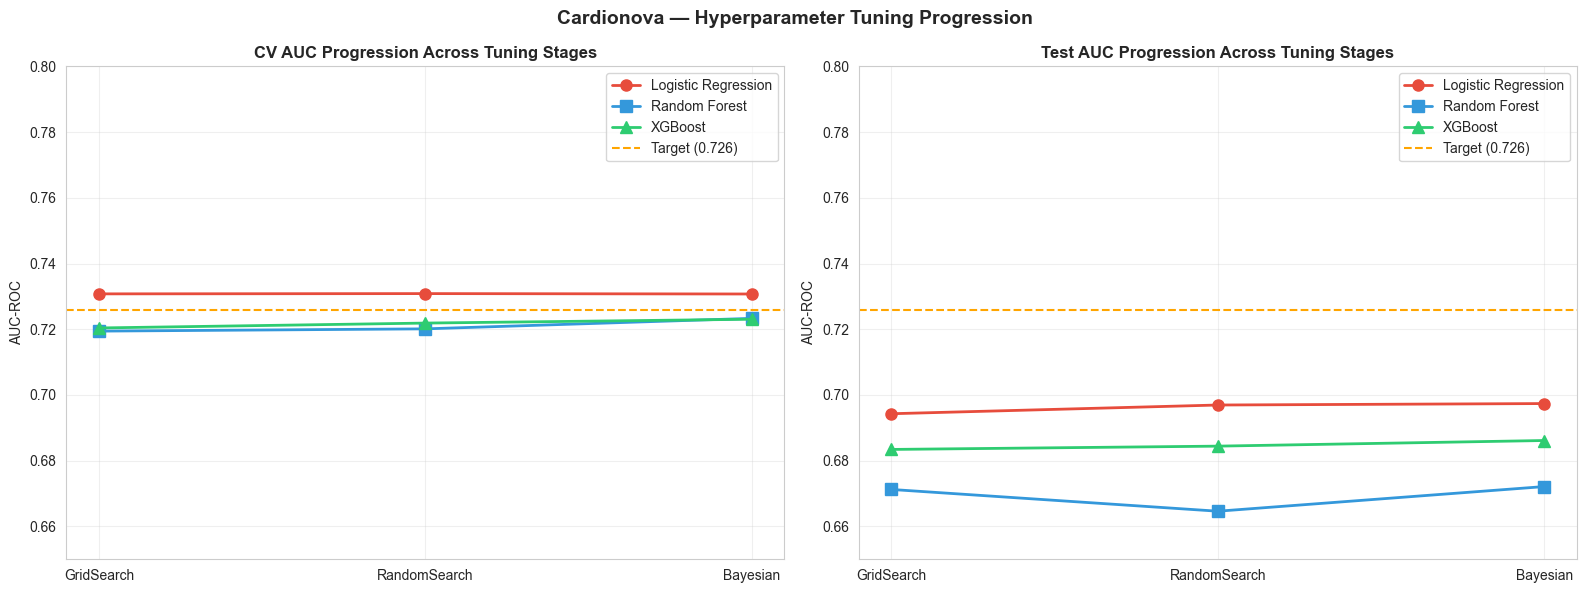

[✓] Saved: reports/08_tuning_progression.png

  ✅  ADVANCED TUNING COMPLETE
  Champion: Logistic Regression via RandomSearch
  CV AUC:   0.7309
  Test AUC: 0.6970
  Threshold:0.448
  Saved → data/models/cardionova_model.pkl
  Next  → Module 3: SHAP Explainability


In [8]:
# ============================================================
# CELL 5: Full comparison — Grid vs Random vs Bayesian
# Pick the absolute best model across all tuning stages
# ============================================================

import joblib

all_stage_results = []

stages = [
    ("GridSearch",  grid_results),
    ("RandomSearch", random_results),
]
if SKOPT_AVAILABLE:
    stages.append(("Bayesian", bayes_results))

for stage_name, stage_dict in stages:
    for model_name, r in stage_dict.items():
        all_stage_results.append({
            "Stage":      stage_name,
            "Model":      model_name,
            "CV AUC":     round(r["cv_auc"],   4),
            "Test AUC":   round(r["test_auc"],  4),
            "CV-Test Gap":round(r["cv_auc"] - r["test_auc"], 4),
        })

results_all = pd.DataFrame(all_stage_results).sort_values("CV AUC", ascending=False)
print("\n" + "=" * 70)
print("  FULL TUNING COMPARISON: GridSearch vs Random vs Bayesian")
print("=" * 70)
display(results_all)

# ── Find absolute best ────────────────────────────────────
best_row   = results_all.iloc[0]
best_stage = best_row["Stage"]
best_model_name = best_row["Model"]

# Retrieve the best model object
stage_map = {"GridSearch": grid_results,
             "RandomSearch": random_results,
             "Bayesian": bayes_results if SKOPT_AVAILABLE else {}}
final_best_model = stage_map[best_stage][best_model_name]["model"]

print(f"\n{'='*55}")
print(f"  🏆  CHAMPION MODEL")
print(f"{'='*55}")
print(f"  Model:       {best_model_name}")
print(f"  Tuning:      {best_stage}")
print(f"  CV AUC:      {best_row['CV AUC']:.4f}")
print(f"  Test AUC:    {best_row['Test AUC']:.4f}")
print(f"  Overfitting: {best_row['CV-Test Gap']:.4f}")

# ── Visualization: progression across stages ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
models_to_plot = ["Logistic Regression", "Random Forest", "XGBoost"]
stage_names    = [s[0] for s in stages]
colors_model   = {"Logistic Regression": "#e74c3c",
                   "Random Forest":       "#3498db",
                   "XGBoost":             "#2ecc71"}
markers        = {"Logistic Regression": "o",
                   "Random Forest":       "s",
                   "XGBoost":             "^"}

for mname in models_to_plot:
    cv_aucs   = []
    test_aucs = []
    for stage_name, stage_dict in stages:
        if mname in stage_dict:
            cv_aucs.append(stage_dict[mname]["cv_auc"])
            test_aucs.append(stage_dict[mname]["test_auc"])

    axes[0].plot(stage_names[:len(cv_aucs)], cv_aucs,
                 marker=markers[mname], color=colors_model[mname],
                 linewidth=2, markersize=8, label=mname)
    axes[1].plot(stage_names[:len(test_aucs)], test_aucs,
                 marker=markers[mname], color=colors_model[mname],
                 linewidth=2, markersize=8, label=mname)

axes[0].axhline(y=0.726, color="orange", linestyle="--", label="Target (0.726)")
axes[1].axhline(y=0.726, color="orange", linestyle="--", label="Target (0.726)")
axes[0].set_title("CV AUC Progression Across Tuning Stages", fontweight="bold")
axes[1].set_title("Test AUC Progression Across Tuning Stages", fontweight="bold")
for ax in axes:
    ax.set_ylabel("AUC-ROC")
    ax.set_ylim(0.65, 0.80)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Cardionova — Hyperparameter Tuning Progression",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "08_tuning_progression.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("[✓] Saved: reports/08_tuning_progression.png")

# ── Save the final champion model ─────────────────────────
y_prob_final = final_best_model.predict_proba(X_test)[:, 1]
final_auc    = roc_auc_score(y_test, y_prob_final)

# Find optimal clinical threshold
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_final)
best_thresh = 0.5
best_f1_val = 0.0
for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds):
    f = 2*p*r/(p+r+1e-9)
    if r >= 0.65 and f > best_f1_val:
        best_f1_val = f
        best_thresh = t

joblib.dump({
    "model":             final_best_model,
    "model_name":        f"{best_model_name} ({best_stage})",
    "tuning_stage":      best_stage,
    "feature_names":     FEATURE_NAMES,
    "optimal_threshold": float(best_thresh),
    "cv_auc":            float(best_row["CV AUC"]),
    "test_auc":          float(final_auc),
}, os.path.join(MODELS_DIR, "cardionova_model.pkl"))

results_all.to_csv(os.path.join(REPORTS_DIR, "tuning_comparison.csv"), index=False)

print(f"\n{'='*55}")
print(f"  ✅  ADVANCED TUNING COMPLETE")
print(f"{'='*55}")
print(f"  Champion: {best_model_name} via {best_stage}")
print(f"  CV AUC:   {best_row['CV AUC']:.4f}")
print(f"  Test AUC: {final_auc:.4f}")
print(f"  Threshold:{best_thresh:.3f}")
print(f"  Saved → data/models/cardionova_model.pkl")
print(f"  Next  → Module 3: SHAP Explainability")
